# Notebook Native Agent in Action: `tips.csv`

This notebook shows a context-aware workflow on `tips.csv`: load the dataset, inspect it, ask for analysis ideas, and continue step by step using natural-language notebook cells.

In [1]:
from notebook_native_agent import start_agent, stop_agent, agent_status, agent_symbols, pause_agent, resume_agent, get_state

start_agent()

In [2]:
I have this: tips.csv

Loaded tips.csv
Shape: 244 rows x 7 columns
Columns: ['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [3]:
What analysis can we do on it? 

Dataset overview


,metric,value
0,rows,244
1,columns,8
2,duplicate_rows,1


Column names, data types, and missing values


,column,dtype,non_null,missing,missing_pct
0,total_bill,float64,244,0,0.0
1,tip,float64,244,0,0.0
2,sex,object,244,0,0.0
3,smoker,object,244,0,0.0
4,day,object,244,0,0.0
5,time,object,244,0,0.0
6,size,int64,244,0,0.0
7,tip_pct,float64,244,0,0.0


Summary statistics for numeric fields


,count,mean,std,min,25%,50%,75%,max
total_bill,244.0,19.785943,8.902412,3.070000,13.347500,17.79500,24.127500,50.810000
tip,244.0,2.998279,1.383638,1.000000,2.000000,2.90000,3.562500,10.000000
size,244.0,2.569672,0.951100,1.000000,2.000000,2.00000,3.000000,6.000000
tip_pct,244.0,0.160803,0.061072,0.035638,0.129127,0.15477,0.191475,0.710345


Target metric summaries


,count,mean,std,min,5%,25%,50%,75%,95%,max
total_bill,244.0,19.785943,8.902412,3.070000,9.557500,13.347500,17.79500,24.127500,38.061000,50.810000
tip,244.0,2.998279,1.383638,1.000000,1.440000,2.000000,2.90000,3.562500,5.195500,10.000000
tip_pct,244.0,0.160803,0.061072,0.035638,0.078663,0.129127,0.15477,0.191475,0.240738,0.710345
size,244.0,2.569672,0.951100,1.000000,2.000000,2.000000,2.00000,3.000000,4.000000,6.000000


Party size distribution


,count,pct
size,,
1,4,1.64
2,156,63.93
3,38,15.57
4,37,15.16
5,5,2.05
6,4,1.64


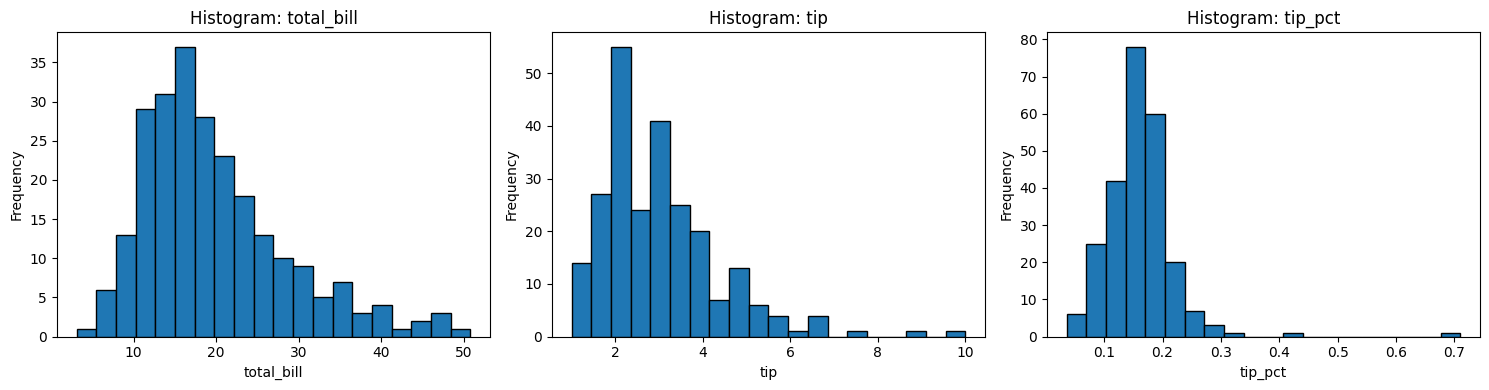

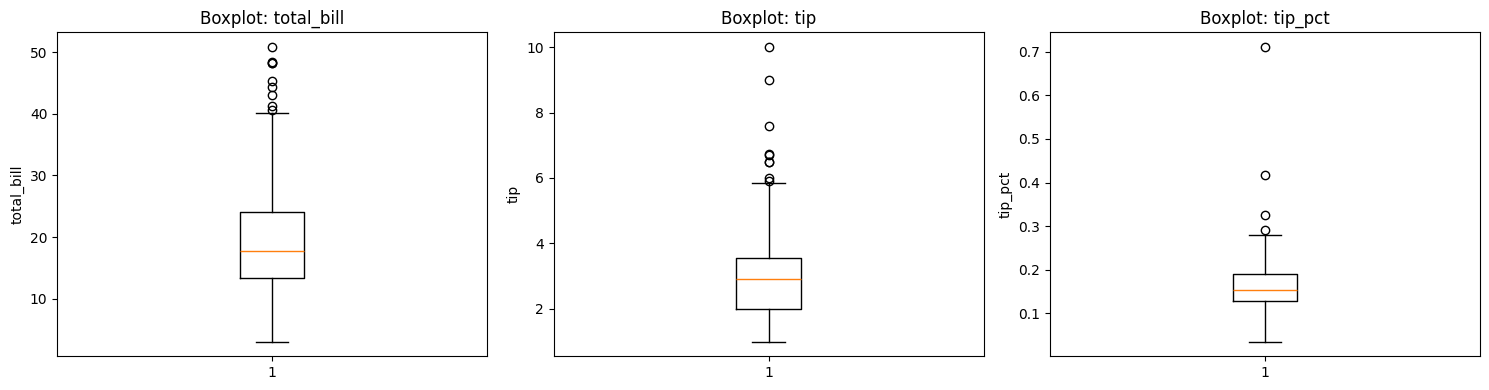

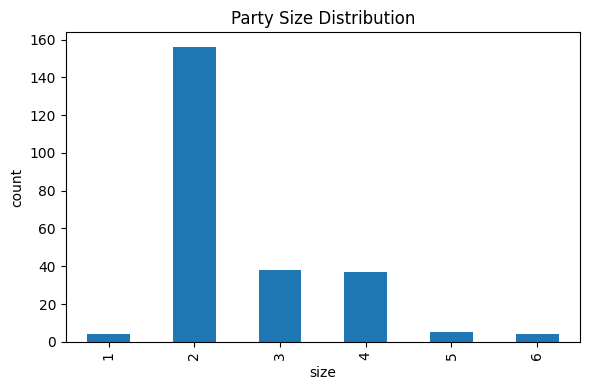

Frequency table: day


,count,pct
day,,
Sat,87,35.66
Sun,76,31.15
Thur,62,25.41
Fri,19,7.79


Frequency table: time


,count,pct
time,,
Dinner,176,72.13
Lunch,68,27.87


Frequency table: smoker


,count,pct
smoker,,
No,151,61.89
Yes,93,38.11


Frequency table: sex


,count,pct
sex,,
Male,157,64.34
Female,87,35.66


In [4]:
Basic dataset overview
- Number of rows and columns
- Column names and data types
- Missing values and duplicates
- Summary statistics for numeric fields

Target metrics to create
- Tip amount distribution
- Bill amount distribution
- tip_pct = tip / total_bill if those columns exist
- Party size distribution if a size column exists

Univariate analysis
- Histograms of bill, tip, and tip percentage
- Boxplots to spot skew and outliers
- Frequency tables for categorical columns like day, time, smoker, sex

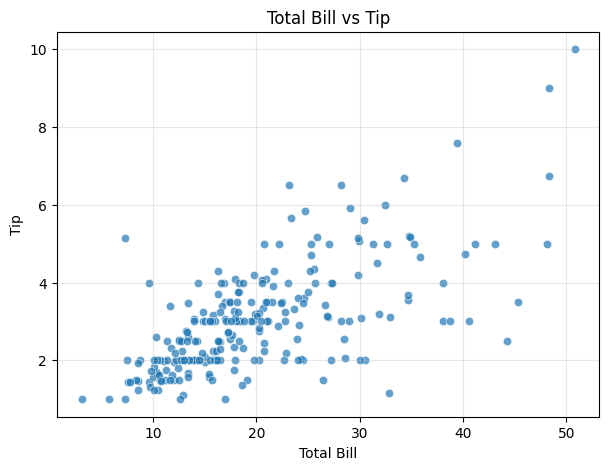

Correlation matrix for numeric columns:


,total_bill,tip,size,tip_pct,tip_pct_pct
total_bill,1.000,0.676,0.598,-0.339,-0.339
tip,0.676,1.000,0.489,0.342,0.342
size,0.598,0.489,1.000,-0.143,-0.143
tip_pct,-0.339,0.342,-0.143,1.000,1.000
tip_pct_pct,-0.339,0.342,-0.143,1.000,1.000


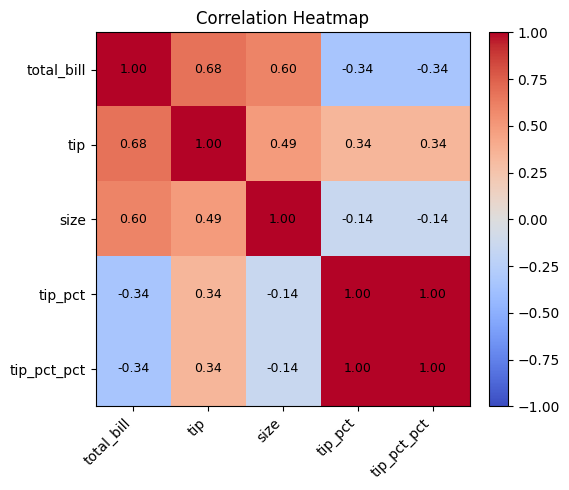

Tip percentage summary by group (values are percentages):


<auto_agent:4:attempt:1>:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


,comparison,group,count,mean_tip_pct,median_tip_pct,std_tip_pct
0,time,Lunch,68,16.41,15.41,4.02
1,time,Dinner,176,15.95,15.54,6.75
2,is_weekend,Weekday,81,16.33,15.38,4.08
3,is_weekend,Weekend,163,15.96,15.56,6.91
4,smoker,No,151,15.93,15.56,3.99
5,smoker,Yes,93,16.32,15.38,8.51
6,size_group,1-2,160,16.70,15.67,6.74
7,size_group,3-4,75,14.91,14.96,4.38
8,size_group,5-6,9,14.80,14.09,5.50
9,size_group,7+,0,NaN,NaN,NaN


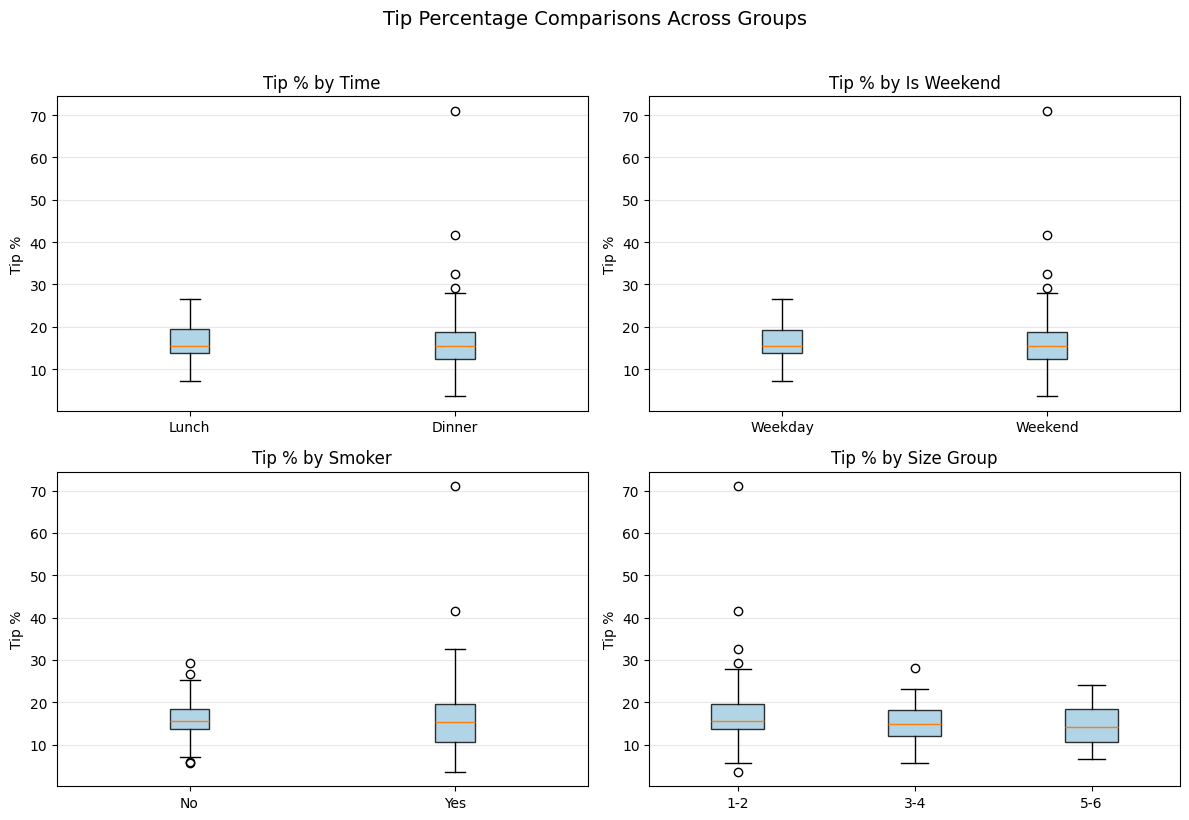

In [5]:
4. Relationship analysis
- Scatter plot of total bill vs. tip
- Correlation between numeric columns
- Compare tip percentage across groups such as:
- lunch vs dinner
- weekday vs weekend
- smoker vs non-smoker
- party size groups

In [6]:
Group-by summaries
- Average and median tip by day/time
- Average tip percentage by category
- Count of observations per group
- Revenue-style summaries: total bill and total tips by group

Average and median tip by day/time


<auto_agent:5:attempt:1>:67: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead


,day,time,observation_count,avg_tip,median_tip,total_bill,total_tip,avg_tip_pct
0,Fri,Dinner,12,2.940,3.00,235.96,35.28,0.159
1,Fri,Lunch,7,2.383,2.20,89.92,16.68,0.189
2,Sat,Dinner,87,2.993,2.75,1778.40,260.40,0.153
3,Sun,Dinner,76,3.255,3.15,1627.16,247.39,0.167
4,Thur,Dinner,1,3.000,3.00,18.78,3.00,0.160
5,Thur,Lunch,61,2.768,2.30,1077.55,168.83,0.161


Average tip percentage, counts, and totals by category


,group_by,group_value,observation_count,avg_tip,median_tip,total_bill,total_tip,avg_tip_pct
0,sex,Female,87,2.833,2.750,1570.95,246.51,0.166
1,sex,Male,157,3.090,3.000,3256.82,485.07,0.158
2,smoker,No,151,2.992,2.740,2897.43,451.77,0.159
3,smoker,Yes,93,3.009,3.000,1930.34,279.81,0.163
4,day,Fri,19,2.735,3.000,325.88,51.96,0.170
5,day,Sat,87,2.993,2.750,1778.40,260.40,0.153
6,day,Sun,76,3.255,3.150,1627.16,247.39,0.167
7,day,Thur,62,2.771,2.305,1096.33,171.83,0.161
8,time,Dinner,176,3.103,3.000,3660.30,546.07,0.160
9,time,Lunch,68,2.728,2.250,1167.47,185.51,0.164


Revenue-style summaries by group


,grouping,day,observation_count,avg_tip,median_tip,total_bill,total_tip,avg_tip_pct,time,sex,smoker
0,day,Fri,19,2.735,3.000,325.88,51.96,0.170,NaN,NaN,NaN
1,day,Sat,87,2.993,2.750,1778.40,260.40,0.153,NaN,NaN,NaN
2,day,Sun,76,3.255,3.150,1627.16,247.39,0.167,NaN,NaN,NaN
3,day,Thur,62,2.771,2.305,1096.33,171.83,0.161,NaN,NaN,NaN
4,time,NaN,176,3.103,3.000,3660.30,546.07,0.160,Dinner,NaN,NaN
5,time,NaN,68,2.728,2.250,1167.47,185.51,0.164,Lunch,NaN,NaN
6,sex,NaN,87,2.833,2.750,1570.95,246.51,0.166,NaN,Female,NaN
7,sex,NaN,157,3.090,3.000,3256.82,485.07,0.158,NaN,Male,NaN
8,smoker,NaN,151,2.992,2.740,2897.43,451.77,0.159,NaN,NaN,No
9,smoker,NaN,93,3.009,3.000,1930.34,279.81,0.163,NaN,NaN,Yes


Created grouped_summary_tables with: tip_by_day_time_summary, category_group_summary, revenue_style_summary


,metric,value
0,Source dataframe,relationship_df
1,Rows analyzed,244
2,Average tip %,16.080258
3,Median tip %,15.476977
4,IQR lower bound for low-tip outliers,3.560517
5,IQR upper bound for high-tip outliers,28.499767
6,Low-tip outlier count,0
7,High-tip outlier count,4


Low tip percentage outliers:
None found using the IQR rule.
High tip percentage outliers:


,total_bill,tip,tip_pct_percent,size,day,time,smoker,sex
0,7.25,5.15,71.034,2,Sun,Dinner,Yes,Male
1,9.60,4.00,41.667,2,Sun,Dinner,Yes,Female
2,3.07,1.00,32.573,1,Sat,Dinner,Yes,Female
3,11.61,3.39,29.199,2,Sat,Dinner,No,Male


,metric,value
0,Large-bill threshold,32.235
1,Small-tip threshold (%),9.85502
2,Flagged rows,7
3,Threshold note,Using 90th percentile bills and 10th percentil...


Very large bills with small tips:


,total_bill,tip,tip_pct_percent,size,day,time,smoker,sex
0,45.35,3.50,7.718,3,Sun,Dinner,Yes,Male
1,44.30,2.50,5.643,3,Sat,Dinner,Yes,Female
2,40.55,3.00,7.398,2,Sun,Dinner,Yes,Male
3,38.73,3.00,7.746,4,Sat,Dinner,Yes,Male
4,38.01,3.00,7.893,4,Sat,Dinner,Yes,Male
5,32.90,3.11,9.453,2,Sun,Dinner,Yes,Male
6,32.83,1.17,3.564,2,Sat,Dinner,Yes,Male


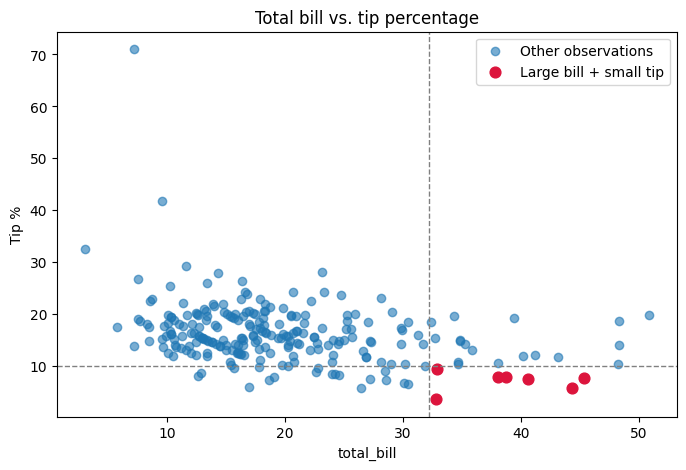

Tip behavior by exact party size:


,size,observations,avg_tip_pct,median_tip_pct,avg_bill,avg_tip
0,1,4,21.729,20.275,7.242,1.438
1,2,156,16.572,15.610,16.448,2.582
2,3,38,15.216,15.932,23.278,3.393
3,4,37,14.595,14.670,28.614,4.135
4,5,5,14.150,12.139,30.068,4.028
5,6,4,15.623,16.289,34.830,5.225


Tip behavior by grouped party size:


,party_size_group,observations,avg_tip_pct,median_tip_pct,avg_bill,avg_tip
0,Small (1-2),160,16.701,15.666,16.218,2.554
1,Medium (3-4),75,14.909,14.963,25.910,3.759
2,Large (5+),9,14.804,14.094,32.184,4.560


Large parties average 1.90 percentage points lower tip percentages than small parties.


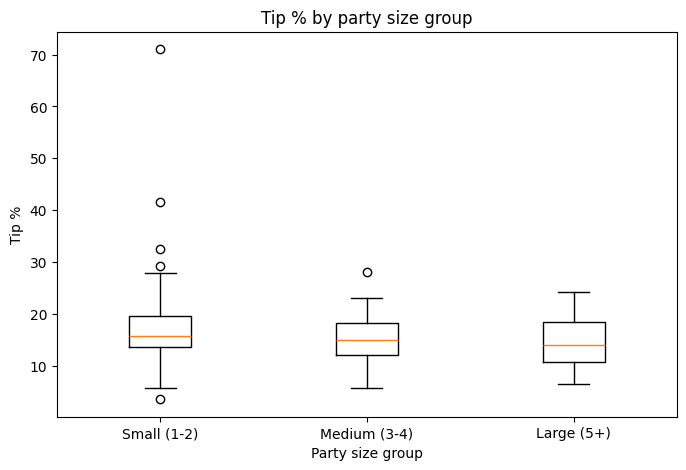

Correlation between party size and tip %: -0.143
Completed outlier and behavior analysis.


In [7]:
Outlier and behavior analysis
- Identify unusually high or low tip percentages
- Look for very large bills with small tips
- Check whether larger parties tip differently than smaller ones

In [8]:
Statistical testing ideas
- T-tests or nonparametric tests for two-group comparisons
- ANOVA/Kruskal-Wallis for multi-group comparisons
- Simple regression: predict tip from bill, size, time, and other categories

Statistical testing section
Using dataframe with 244 rows and 9 columns.

Two-group comparisons on tip_pct


,comparison,value,group_1,group_2,n_group_1,n_group_2,mean_group_1,mean_group_2,median_group_1,median_group_2,mean_diff_g1_minus_g2,levene_pvalue,welch_t_stat,welch_t_pvalue,mannwhitney_u_stat,mannwhitney_pvalue,cohens_d
0,time,tip_pct,Dinner,Lunch,176,68,0.1595,0.1641,0.1554,0.1541,-0.0046,0.1201,-0.6540,0.5138,5391.0,0.2307,-0.0754
1,smoker,tip_pct,No,Yes,151,93,0.1593,0.1632,0.1556,0.1538,-0.0039,0.0002,-0.4112,0.6817,7333.5,0.5607,-0.0632
2,sex,tip_pct,Female,Male,87,157,0.1665,0.1577,0.1556,0.1535,0.0088,0.4986,1.1433,0.2542,7619.0,0.1352,0.1448
3,is_weekend,tip_pct,Weekend,Weekday,163,81,0.1596,0.1633,0.1556,0.1538,-0.0037,0.0809,-0.5301,0.5965,6069.0,0.3055,-0.0612



Group summary for day on tip_pct


,day,n,mean,median,std
0,Fri,19,0.1699,0.1556,0.0477
1,Sat,87,0.1532,0.1518,0.0513
2,Sun,76,0.1669,0.1611,0.0847
3,Thur,62,0.1613,0.1538,0.0387



Group summary for size on tip_pct


,size,n,mean,median,std
0,1,4,0.2173,0.2028,0.0803
1,2,156,0.1657,0.1561,0.0668
2,3,38,0.1522,0.1593,0.0455
3,4,37,0.1459,0.1467,0.0424
4,5,5,0.1415,0.1214,0.0677
5,6,4,0.1562,0.1629,0.0422



Multi-group comparisons on tip_pct


,comparison,value,groups_tested,n_groups,anova_f_stat,anova_pvalue,kruskal_h_stat,kruskal_pvalue
0,day,tip_pct,"Fri, Sat, Sun, Thur",4,0.8480,0.4688,1.8347,0.6074
1,size,tip_pct,"1, 2, 3, 4, 5, 6",6,1.6007,0.1606,7.4862,0.1869



statsmodels is not installed, so regression was skipped.


---

### Manually rerun after installing `statsmodels`

The agent-generated code safely skipped the regression step because `statsmodels` was not installed.

To see the regression results, we install it first:

```bash
pip install statsmodels
```
Then copy-paste from above and rerun it.

In [9]:
import pandas as pd
import numpy as np
from typing import Optional, Tuple

try:
    display
except NameError:
    from IPython.display import display

try:
    from scipy import stats
except ImportError:
    stats = None

try:
    import statsmodels.formula.api as smf
except ImportError:
    smf = None


def prepare_stats_df(df: pd.DataFrame) -> pd.DataFrame:
    """Return a clean dataframe for statistical testing and regression."""
    out = df.copy()
    if 'tip_pct' not in out.columns and {'tip', 'total_bill'}.issubset(out.columns):
        out = out.loc[out['total_bill'].ne(0)].copy()
        out['tip_pct'] = out['tip'] / out['total_bill']
    if 'tip_pct' in out.columns:
        out['tip_pct'] = out['tip_pct'].replace([np.inf, -np.inf], np.nan)
    if 'day' in out.columns:
        out['is_weekend'] = np.where(out['day'].isin(['Sat', 'Sun']), 'Weekend', 'Weekday')
    return out


def cohens_d(x: pd.Series, y: pd.Series) -> float:
    """Compute Cohen's d for two independent samples."""
    x = pd.Series(x).dropna().astype(float)
    y = pd.Series(y).dropna().astype(float)
    if len(x) < 2 or len(y) < 2:
        return np.nan
    pooled_var = (((len(x) - 1) * x.var(ddof=1)) + ((len(y) - 1) * y.var(ddof=1))) / (len(x) + len(y) - 2)
    if pd.isna(pooled_var) or pooled_var <= 0:
        return np.nan
    return (x.mean() - y.mean()) / np.sqrt(pooled_var)


def run_two_group_tests(df: pd.DataFrame, group_col: str, value_col: str = 'tip_pct') -> Optional[pd.DataFrame]:
    """Run Welch t-test and Mann-Whitney U test for a two-group comparison."""
    required = {group_col, value_col}
    if not required.issubset(df.columns):
        return None

    sub = df[[group_col, value_col]].dropna().copy()
    unique_groups = list(pd.unique(sub[group_col]))
    if len(unique_groups) != 2:
        return None

    g1, g2 = unique_groups
    x = sub.loc[sub[group_col] == g1, value_col].astype(float)
    y = sub.loc[sub[group_col] == g2, value_col].astype(float)
    if len(x) < 2 or len(y) < 2:
        return None

    try:
        levene_p = stats.levene(x, y).pvalue
    except Exception:
        levene_p = np.nan

    try:
        welch = stats.ttest_ind(x, y, equal_var=False, nan_policy='omit')
        welch_stat = welch.statistic
        welch_p = welch.pvalue
    except Exception:
        welch_stat = np.nan
        welch_p = np.nan

    try:
        mw = stats.mannwhitneyu(x, y, alternative='two-sided')
        mw_stat = mw.statistic
        mw_p = mw.pvalue
    except Exception:
        mw_stat = np.nan
        mw_p = np.nan

    result = pd.DataFrame([
        {
            'comparison': group_col,
            'value': value_col,
            'group_1': g1,
            'group_2': g2,
            'n_group_1': int(len(x)),
            'n_group_2': int(len(y)),
            'mean_group_1': x.mean(),
            'mean_group_2': y.mean(),
            'median_group_1': x.median(),
            'median_group_2': y.median(),
            'mean_diff_g1_minus_g2': x.mean() - y.mean(),
            'levene_pvalue': levene_p,
            'welch_t_stat': welch_stat,
            'welch_t_pvalue': welch_p,
            'mannwhitney_u_stat': mw_stat,
            'mannwhitney_pvalue': mw_p,
            'cohens_d': cohens_d(x, y),
        }
    ])
    return result


def run_multi_group_tests(df: pd.DataFrame, group_col: str, value_col: str = 'tip_pct') -> Tuple[Optional[pd.DataFrame], Optional[pd.DataFrame]]:
    """Run one-way ANOVA and Kruskal-Wallis for a multi-group comparison."""
    required = {group_col, value_col}
    if not required.issubset(df.columns):
        return None, None

    sub = df[[group_col, value_col]].dropna().copy()
    summary = (
        sub.groupby(group_col)[value_col]
        .agg(n='count', mean='mean', median='median', std='std')
        .reset_index()
        .sort_values(group_col)
    )

    grouped_arrays = []
    valid_groups = []
    for group_name, values in sub.groupby(group_col)[value_col]:
        arr = values.astype(float)
        if len(arr) >= 2:
            grouped_arrays.append(arr.values)
            valid_groups.append(group_name)

    if len(grouped_arrays) < 3:
        return None, summary

    try:
        anova = stats.f_oneway(*grouped_arrays)
        anova_stat = anova.statistic
        anova_p = anova.pvalue
    except Exception:
        anova_stat = np.nan
        anova_p = np.nan

    try:
        kw = stats.kruskal(*grouped_arrays)
        kw_stat = kw.statistic
        kw_p = kw.pvalue
    except Exception:
        kw_stat = np.nan
        kw_p = np.nan

    result = pd.DataFrame([
        {
            'comparison': group_col,
            'value': value_col,
            'groups_tested': ', '.join(map(str, valid_groups)),
            'n_groups': len(valid_groups),
            'anova_f_stat': anova_stat,
            'anova_pvalue': anova_p,
            'kruskal_h_stat': kw_stat,
            'kruskal_pvalue': kw_p,
        }
    ])
    return result, summary


def fit_tip_regression(df: pd.DataFrame) -> Tuple[Optional[pd.DataFrame], Optional[pd.DataFrame]]:
    """Fit an OLS model predicting tip from bill size and available categories."""
    if smf is None or 'tip' not in df.columns:
        return None, None

    numeric_predictors = [col for col in ['total_bill', 'size'] if col in df.columns]
    categorical_predictors = [col for col in ['time', 'smoker', 'sex', 'day'] if col in df.columns]
    model_cols = ['tip'] + numeric_predictors + categorical_predictors
    model_df = df[model_cols].dropna().copy()

    if not numeric_predictors and not categorical_predictors:
        return None, None
    if len(model_df) < 5:
        return None, None

    formula_terms = numeric_predictors + [f'C({col})' for col in categorical_predictors]
    formula = 'tip ~ ' + ' + '.join(formula_terms)
    model = smf.ols(formula=formula, data=model_df).fit()

    metrics_df = pd.DataFrame([
        {
            'formula': formula,
            'n_obs': int(model.nobs),
            'r_squared': model.rsquared,
            'adj_r_squared': model.rsquared_adj,
            'aic': model.aic,
            'bic': model.bic,
            'f_pvalue': model.f_pvalue,
        }
    ])

    coef_df = model.summary2().tables[1].reset_index().rename(columns={'index': 'term'})
    return metrics_df, coef_df


base_stats_df = eda_df.copy() if 'eda_df' in globals() else tips_df.copy()
analysis_df = prepare_stats_df(base_stats_df)

print('Statistical testing section')
print(f'Using dataframe with {len(analysis_df)} rows and {analysis_df.shape[1]} columns.')

if stats is None:
    print('scipy is not installed, so hypothesis tests were skipped.')
else:
    two_group_results = []
    for group_col in ['time', 'smoker', 'sex', 'is_weekend']:
        test_df = run_two_group_tests(analysis_df, group_col=group_col, value_col='tip_pct')
        if test_df is not None:
            two_group_results.append(test_df)

    if two_group_results:
        print('\nTwo-group comparisons on tip_pct')
        display(pd.concat(two_group_results, ignore_index=True).round(4))
    else:
        print('\nNo eligible two-group comparisons were found.')

    multi_group_results = []
    for group_col in ['day', 'size']:
        test_df, group_summary = run_multi_group_tests(analysis_df, group_col=group_col, value_col='tip_pct')
        if group_summary is not None:
            print(f'\nGroup summary for {group_col} on tip_pct')
            display(group_summary.round(4))
        if test_df is not None:
            multi_group_results.append(test_df)

    if multi_group_results:
        print('\nMulti-group comparisons on tip_pct')
        display(pd.concat(multi_group_results, ignore_index=True).round(4))
    else:
        print('\nNo eligible multi-group comparisons were found.')

if smf is None:
    print('\nstatsmodels is not installed, so regression was skipped.')
else:
    regression_metrics_df, regression_coef_df = fit_tip_regression(analysis_df)
    if regression_metrics_df is not None and regression_coef_df is not None:
        print('\nOLS regression: predict tip from bill, size, and available categories')
        display(regression_metrics_df.round(4))
        display(regression_coef_df.round(4))
    else:
        print('\nRegression could not be fit with the available columns/data.')


Statistical testing section
Using dataframe with 244 rows and 9 columns.

Two-group comparisons on tip_pct


,comparison,value,group_1,group_2,n_group_1,n_group_2,mean_group_1,mean_group_2,median_group_1,median_group_2,mean_diff_g1_minus_g2,levene_pvalue,welch_t_stat,welch_t_pvalue,mannwhitney_u_stat,mannwhitney_pvalue,cohens_d
0,time,tip_pct,Dinner,Lunch,176,68,0.1595,0.1641,0.1554,0.1541,-0.0046,0.1201,-0.6540,0.5138,5391.0,0.2307,-0.0754
1,smoker,tip_pct,No,Yes,151,93,0.1593,0.1632,0.1556,0.1538,-0.0039,0.0002,-0.4112,0.6817,7333.5,0.5607,-0.0632
2,sex,tip_pct,Female,Male,87,157,0.1665,0.1577,0.1556,0.1535,0.0088,0.4986,1.1433,0.2542,7619.0,0.1352,0.1448
3,is_weekend,tip_pct,Weekend,Weekday,163,81,0.1596,0.1633,0.1556,0.1538,-0.0037,0.0809,-0.5301,0.5965,6069.0,0.3055,-0.0612



Group summary for day on tip_pct


,day,n,mean,median,std
0,Fri,19,0.1699,0.1556,0.0477
1,Sat,87,0.1532,0.1518,0.0513
2,Sun,76,0.1669,0.1611,0.0847
3,Thur,62,0.1613,0.1538,0.0387



Group summary for size on tip_pct


...


Multi-group comparisons on tip_pct


,comparison,value,groups_tested,n_groups,anova_f_stat,anova_pvalue,kruskal_h_stat,kruskal_pvalue
0,day,tip_pct,"Fri, Sat, Sun, Thur",4,0.8480,0.4688,1.8347,0.6074
1,size,tip_pct,"1, 2, 3, 4, 5, 6",6,1.6007,0.1606,7.4862,0.1869



OLS regression: predict tip from bill, size, and available categories


,formula,n_obs,r_squared,adj_r_squared,aic,bic,f_pvalue
0,tip ~ total_bill + size + C(time) + C(smoker) ...,244,0.4701,0.452,712.9553,744.4298,0.0


,term,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
0,Intercept,0.8038,0.3527,2.2790,0.0236,0.1090,1.4987
1,C(time)[T.Lunch],0.0681,0.4446,0.1532,0.8783,-0.8078,0.9441
2,C(smoker)[T.Yes],-0.0864,0.1466,-0.5895,0.5561,-0.3752,0.2024
3,C(sex)[T.Male],-0.0324,0.1416,-0.2291,0.8190,-0.3114,0.2466
4,C(day)[T.Sat],-0.1215,0.3097,-0.3921,0.6953,-0.7317,0.4888
5,C(day)[T.Sun],-0.0255,0.3213,-0.0793,0.9369,-0.6585,0.6075
6,C(day)[T.Thur],-0.1623,0.3934,-0.4124,0.6804,-0.9373,0.6128
7,total_bill,0.0945,0.0096,9.8410,0.0000,0.0756,0.1134
8,size,0.1760,0.0895,1.9658,0.0505,-0.0004,0.3524


<auto_agent:9:attempt:1>:93: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
<auto_agent:9:attempt:1>:93: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


Using `relationship_df` with 244 rows for tipping analysis.

Quick takeaways
- Bigger bills vs bigger tips: correlation = 0.676 (a fairly strong linear relationship).
- Bill size vs tip percentage: correlation = -0.339 (a moderate linear relationship).
- Meal time: `Lunch` has the higher average tip % (16.41%) vs `Dinner` (15.95%).
- Weekend vs weekday: `Weekday` has the higher average tip % (16.33%) vs `Weekend` (15.96%).
- Party size groups: `1-2` has the higher average tip % (16.70%) vs `5-6` (14.80%).
- Largest systematic gap among checked groups: `size_group` with a 1.90 percentage-point spread in average tip %.

Correlation summary


<auto_agent:9:attempt:1>:93: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


,question,metric,value,interpretation
0,Do bigger bills come with bigger absolute tips?,"corr(total_bill, tip)",0.676,a fairly strong linear relationship
1,Does tip percentage stay similar as bills get ...,"corr(total_bill, tip_pct)",-0.339,a moderate linear relationship


Tip behavior across bill-size bins


...

,size_group,n,avg_bill,median_bill,avg_tip,median_tip,avg_tip_pct,median_tip_pct
0,1-2,160,16.22,15.05,2.55,2.39,16.70,15.67
1,3-4,75,25.91,24.08,3.76,3.50,14.91,14.96
2,5-6,9,32.18,29.85,4.56,5.00,14.80,14.09
3,7+,0,NaN,NaN,NaN,NaN,NaN,NaN


Customer-group summaries


,group_variable,sex,n,avg_bill,median_bill,avg_tip,median_tip,avg_tip_pct,median_tip_pct,smoker,time,day,day_type
0,sex,Female,87,18.06,16.40,2.83,2.75,16.65,15.56,NaN,NaN,NaN,NaN
1,sex,Male,157,20.74,18.35,3.09,3.00,15.77,15.35,NaN,NaN,NaN,NaN
2,smoker,NaN,93,20.76,17.92,3.01,3.00,16.32,15.38,Yes,NaN,NaN,NaN
3,smoker,NaN,151,19.19,17.59,2.99,2.74,15.93,15.56,No,NaN,NaN,NaN
4,time,NaN,68,17.17,15.96,2.73,2.25,16.41,15.41,NaN,Lunch,NaN,NaN
5,time,NaN,176,20.80,18.39,3.10,3.00,15.95,15.54,NaN,Dinner,NaN,NaN
6,day,NaN,19,17.15,15.38,2.73,3.00,16.99,15.56,NaN,NaN,Fri,NaN
7,day,NaN,76,21.41,19.63,3.26,3.15,16.69,16.11,NaN,NaN,Sun,NaN
8,day,NaN,62,17.68,16.20,2.77,2.30,16.13,15.38,NaN,NaN,Thur,NaN
9,day,NaN,87,20.44,18.24,2.99,2.75,15.32,15.18,NaN,NaN,Sat,NaN


Largest average tip % differences by grouping variable


,group_variable,highest_avg_tip_pct_group,highest_avg_tip_pct,lowest_avg_tip_pct_group,lowest_avg_tip_pct,gap_pp
0,size_group,1-2,16.70,5-6,14.80,1.90
1,day,Fri,16.99,Sat,15.32,1.68
2,sex,Female,16.65,Male,15.77,0.88
3,time,Lunch,16.41,Dinner,15.95,0.46
4,smoker,Yes,16.32,No,15.93,0.39
5,day_type,Weekday,16.33,Weekend,15.96,0.37


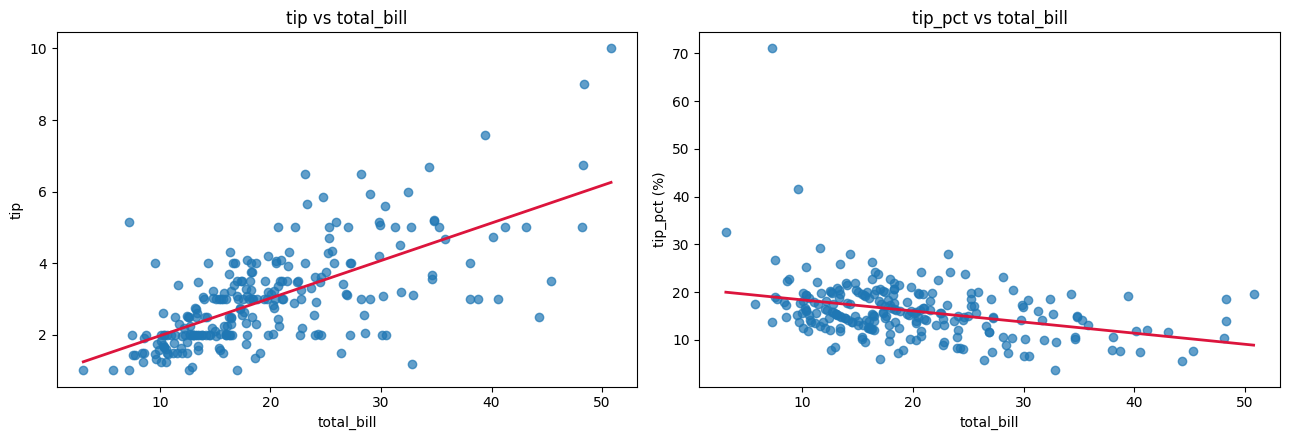

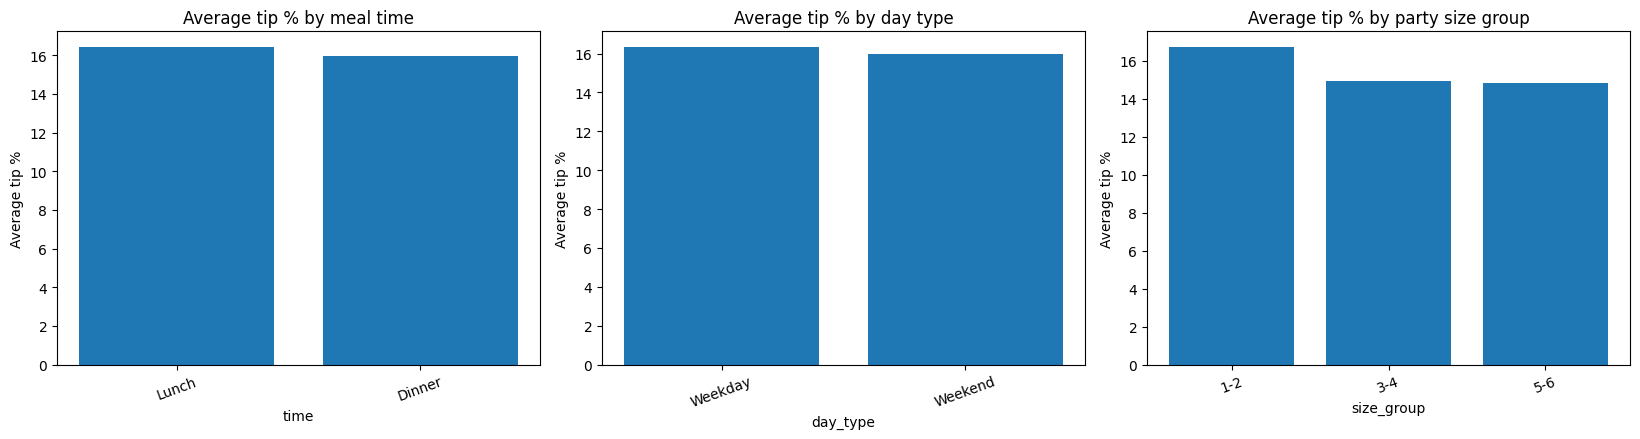

Created analysis objects: tip_question_df, correlation_summary_df, bill_bin_summary_df, meal_summary_df, day_type_summary_df, exact_size_summary_df, size_group_summary_df, customer_group_summary_df, customer_gap_summary_df


In [11]:
- Do bigger bills lead to bigger tips?
- Do people tip a similar percentage regardless of bill size?
- Are tips different at lunch vs dinner?
- Do weekends differ from weekdays?
- Does party size affect tip percentage?
- Are there systematic differences across customer groups?

In [12]:
agent_symbols()

{'Path': {'type': 'type',
          'symbol_kind': 'class',
          'signature': '(*args, **kwargs)',
          'docstring': 'PurePath subclass that can make system calls.\n'
                       '\n'
                       'Path represents a filesystem path but unlike PurePath, '
                       'also offers\n'
                       'methods to do system calls on path objects. Depending '
                       'on your system,\n'
                       'instantiating a Path will return either a PosixPath '
                       'o...',
          'public_member_names': ['absolute',
                                  'anchor',
                                  'as_posix',
                                  'as_uri',
                                  'chmod',
                                  'cwd',
                                  'drive',
                                  'exists',
                                  'expanduser',
                                  'glob',
  

In [13]:
agent_status()

{'started': True,
 'paused': False,
 'agent_name': 'Notebook Native Agent',
 'provider': 'openai',
 'auto_execute': True,
 'allow_fallback_codegen': True,
 'use_model_classifier': False,
 'echo_context': True,
 'brain_model': 'gpt-5.4',
 'summarizer_model': 'gpt-5.4-mini',
 'interpreter_model': 'gpt-5.4-mini',
 'repair_model': 'gpt-5.4',
 'counts': {'cells': 245,
            'execs': 9,
            'active_symbols': 164,
            'artifacts': 0,
            'pending_proposals': 2},
 'current_cell': {'cell_id': 246,
                  'cell_kind': 'python',
                  'linked_exec_id': None}}
